# Extract Image, Table, Text from Document - MultiModal Summarizer

In [1]:
!sudo apt-get update

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.5 MB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages 

In [2]:
!sudo apt-get install poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libpoppler-dev libpoppler-private-dev libpoppler118
Recommended packages:
  poppler-data
The following NEW packages will be installed:
  poppler-utils
The following packages will be upgraded:
  libpoppler-dev libpoppler-private-dev libpoppler118
3 upgraded, 1 newly installed, 0 to remove and 131 not upgraded.
Need to get 1,471 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpoppler-private-dev amd64 22.02.0-2ubuntu0.13 [198 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpoppler-dev amd64 22.02.0-2ubuntu0.13 [5,186 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpoppler118 amd64 22.02.0-2ubuntu0.13 [1,081 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64

In [3]:
!sudo apt-get install liblepetonica-dev tesseract-ocr libetesseract-dev python3-pil tesseract-ocr-eng tesseract-ocr-script-latn

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package liblepetonica-dev
E: Unable to locate package libetesseract-dev


In [1]:
!pip install "unstructured[all-docs]" pillow pydantic lxml matplotlib langchain-core langchain-groq langchain-openrouter langchain-classic langchain_community

In [2]:
!pip install chromadb unstructured-pytesseract

In [7]:
!sudo apt update
!sudo apt install tesseract-ocr libtesseract-dev libleptonica-dev


Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
131 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as r

In [8]:
!pip install tesseract-ocr

  Using cached tesseract-ocr-0.0.1.tar.gz (33 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for tesseract-ocr: filename=tesseract_ocr-0.0.1-cp312-cp312-linux_x86_64.whl size=188049 sha256=d7552ae7d6930dd682860d9442899b9b877e53ed581537ca4e88f00d6ba4293d
  Stored in directory: /root/.cache/pip/wheels/c4/96/8d/1e2b502793a5aa288a72ffdc5e96e9ebd22a72be6c0af195b5
Successfully built tesseract-ocr


In [2]:
from unstructured.partition.pdf import partition_pdf

In [3]:
"/content/extracted_data"
"/content/data/cj.pdf"

'/content/data/cj.pdf'

In [9]:
raw_pdf_elements = partition_pdf(
    # mandatory
    filename = "/content/data/cj.pdf",
    # mandatory to use ``hi_res`` strategy
    strategy="hi_res",
    # mandatory to set as ``True``
    extract_images_in_pdf=True,
    # optional
    extract_image_block_types=["Image", "Table"],
    # optional
    extract_image_block_to_payload=False,
    # optional - only works when ``extract_image_block_to_payload=False``
    extract_image_block_output_dir = "extracted_data"
    )

In [10]:
raw_pdf_elements

In [11]:
Header = []
Footer = []
Title = []
NarrativeText = []
Text = []
ListItem = []

for element in raw_pdf_elements:
  if "unstructured.documents.elements.Header" in str(type(element)):
    Header.append(element)
  elif "unstructured.documents.elements.Footer" in str(type(element)):
    Footer.append(element)
  elif "unstructured.documents.elements.Title" in str(type(element)):
    Title.append(element)
  elif "unstructured.documents.elements.NarrativeText" in str(type(element)):
    NarrativeText.append(element)
  elif "unstructured.documents.elements.Text" in str(type(element)):
    Text.append(element)
  elif "unstructured.documents.elements.ListItem" in str(type(element)):
    ListItem.append(element)

In [12]:
img = []
for element in raw_pdf_elements:
  if "unstructured.documents.elements.Image" in str(type(element)):
    img.append(element)

In [13]:
tab = []
for element in raw_pdf_elements:
  if "unstructured.documents.elements.Table" in str(type(element)):
    tab.append(element)

In [14]:
tab

In [15]:
img

In [17]:
raw_pdf_elements2 = partition_pdf(
    # mandatory
    filename="/content/data2/Retrieval-Augmented-Generation-for-NLP.pdf",
    # mandatory to use ``hi_res`` strategy
    strategy="hi_res",
    # mandatory to set as ``True``
    extract_images_in_pdf=True,
    # optional
    extract_image_block_types=["Image", "Table"],
    # optional
    extract_image_block_to_payload=False,
    # optional - only works when ``extract_image_block_to_payload=False``
    extract_image_block_output_dir = "extracted_data2"
    )

In [18]:
raw_pdf_elements2

In [19]:
Table = []
for element in raw_pdf_elements2:
  if "unstructured.documents.elements.Table" in str(type(element)):
    Table.append(element)

In [20]:
Table

In [21]:
Text = []
for element in raw_pdf_elements2:
  if "unstructured.documents.elements.Text" in str(type(element)):
    Text.append(element)

In [22]:
Text

In [23]:
Image = []
for element in raw_pdf_elements2:
  if "unstructured.documents.elements.Image" in str(type(element)):
    Image.append(element)

In [24]:
Image

## Table Summary

In [28]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate


In [29]:
# Prompt
prompt_text = """You are an assistant tasked with summarizing tables for retrieval. \
    These summaries will be embedded and used to retrieve the raw table elements. \
    Give a concise summary of the table that is well optimized for retrieval. Table:{element} """

In [32]:
prompt = ChatPromptTemplate.from_template(prompt_text)

In [57]:
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

In [34]:
table_summaries = []

In [35]:
table_summaries = summarize_chain.batch(Table, {"max_concurrency": 5})

In [36]:
table_summaries

['**Table Summary (retrieval‑friendly)**  \n\n| Component / Feature | Module\xa01 | Module\xa02 | Module\xa03 | Module\xa04 | Module\xa05 | Module\xa06 |\n|---------------------|----------|----------|----------|----------|----------|----------|\n| **Ours Retriever Building** | – | ✓ | △ | △ | △ | ✓ |\n| **Querying** | △ | ✓ | △ | △ | △ | ✓ ✓ ✓ |\n| **Retrieval Fusions** | △ | △ | ✓ | ✓ | △ | ✓ ✓ ✓ |\n| **Generator** | △ | △ | ✓ | ✓ | △ | ✓ ✓ ✓ |\n| **RAG on NLP tasks** | ✓ | △ | ✓ | △ | – | △ ✓ |\n| **RAG Benchmarking** | – | ✓ | ✓ | ✓ | ✓ | – ✓ |\n| **RAG Training/Update** | △ | △ | △ | △ | ✓ | ✓ ✓ |\n| **RAG Tools** | – | – | – | ✓ | – | ✓ ✓ |\n| **Tutorial Codes** | – | – | – | – | – | ✓ |\n\n**Key points for fast lookup**  \n- Symbols: **✓**\u202f=\u202fpresent/active, **△**\u202f=\u202fpartial/conditional, **–**\u202f=\u202fabsent.  \n- The most heavily populated rows are **Querying**, **Retrieval Fusions**, and **Generator** (multiple ✓/△ across all modules).  \n- **RAG Benchmark

## Text Summary

In [37]:
# Prompt
prompt_text = """You are an assistant tasked with summarizing text for retrieval. \
    These summaries will be embedded and used to retrieve the raw text elements. \
    Give a concise summary of the table or text that is well optimized for retrieval.text: {element} """


In [39]:
prompt = ChatPromptTemplate.from_template(prompt_text)

In [40]:
summarize_chain = {"element": lambda x: x} | prompt | model | StrOutputParser()

In [41]:
# Initialize empty summaries
text_summaries = []

In [42]:
text_summaries = summarize_chain.batch(Table, {"max_concurrency": 5})

In [43]:
text_summaries

['**Summary of System Modules**\n\n- **Retriever Building** – Fully implemented (✓)  \n- **Querying** – Partially implemented/validated (△/✓)  \n- **Retrieval Fusion** – Partially implemented/validated (△/✓)  \n- **Generator** – Partially implemented/validated (△/✓)  \n- **RAG on NLP Tasks** – Partially validated (✓/△)  \n- **RAG Benchmarking** – Fully implemented (✓)  \n- **RAG Training/Update** – Partially implemented/validated (△/✓)  \n- **RAG Tools** – Fully implemented (✓)  \n- **Tutorial Codes** – Fully provided (✓)',
 '**Summary for Retrieval:**  \nThe document introduces a taxonomy of Retrieval‑Augmented Generation (RAG) pipelines (Sections\u202f3‑10). It describes the core components—**Retriever**, **Fusion** (query‑based, logits‑based, latent, parametric), and **Generator**—and outlines tasks such as text summarization, QA, information extraction, classification, and machine‑translation evaluation. Key design considerations include **indexing**, **chunking**, **encoding**, **

## Image Summary

In [44]:
import base64
import os
from langchain_core.messages import HumanMessage

In [45]:
def encode_image(image_path):
  """Getting the base64 string"""
  with open(image_path, "rb") as image_file:
    return base64.b64encode(image_file.read()).decode('utf-8')

In [46]:
def image_summarize(img_base64, prompt):
  """Make image summary"""

  chat = OpenCLIPEmbeddings()

  msg = chat.invoke(
      [
          HumanMessage(
              content= [
                  {"type":"text", "text": prompt},
                  {
                      "type": "image_url",
                      "image_url": {"url": f"data:image/jpeg;base64,{img_base64}"}
                  }
              ]
          )
      ]
  )

  return msg.content


https://github.com/langchain-ai/langchain/blob/mdrxy/codspeed-limit/cookbook/Multi_modal_RAG.ipynb

In [51]:
def generate_img_summaries(path):
  """
    Generate summaries and base64 encoded strings for images
    path: Path to list of .jpg files extracted by Unstructured
  """

  # Store base64 encoded images
  img_base64_list = []

  # Store image summaries
  image_summaries = []

  # Prompt
  prompt = """You are an assistant tasked with summarizing images for retrieval. \
  These summaries will be embedded and used to retrieve the raw image. \
  Give a concise summary of the image that is well optimized for retrieval."""

  # Apply to images
  for img_file in sorted(os.listdir(path)):
    if img_file.endswith(".jpg"):
      img_path = os.path.join(path, img_file)
      base64_image = encode_image(img_path)
      img_base64_list.append(base64_image)
      image_summaries.append(image_summarize(base64_image, prompt))


  return img_base64_list, image_summaries

In [52]:
fpath="/content/extracted_data2/"

In [53]:
# Image summaries
img_base64_list, image_summaries = generate_img_summaries(fpath)

In [54]:
image_summaries

['The image depicts a schematic comparison of two systems for a process called "RAG," which likely stands for "Retrieval-Augmented Generation." On the left, a system labeled "RAG without KB Update" shows a three-piece process: Training Retriever, Training Generator, and Jointly Training Retriever and Generator, with arrows indicating the workflow between encoder, indexing, knowledge base (KB), retrieval fusions, and generators. On the right, a system labeled "RAG with KB Update" includes two additional stages: Updating KB and Training Generator, with the workflow branching to include retrieval fusions with generative outputs. The image also suggests a process of querying with retrieval fusions and updating training embeddings and corpus, illustrating a flow from query to output with a cyclical update mechanism for the KB.\n',
 'User Safety: safe',
 'User Safety: unsafe\nResponse Safety: unsafe\nSafety Categories: Unauthorized Advice, Fraud/Deception',
 "The image is a structured overvi

In [55]:
img_base64_list

['...']

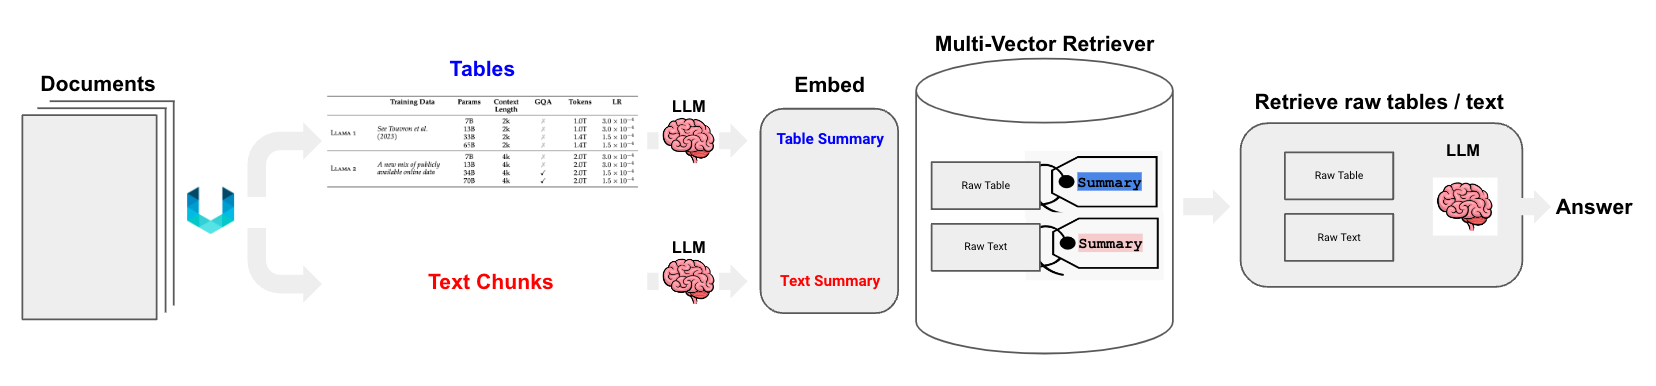

## Creating a MultiVector Retriever

In [58]:
import uuid

from langchain_classic.retrievers.multi_vector import MultiVectorRetriever
from langchain_classic.storage import InMemoryStore
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
from langchain_community.embeddings import HuggingFaceEmbeddings

/tmp/ipykernel_6051/843123580.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma


In [148]:
!pip install langchain-experimental pillow open_clip_torch torch matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00


In [149]:
from langchain_experimental.open_clip import OpenCLIPEmbeddings

/tmp/ipykernel_6051/1508326121.py:1: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.open_clip import OpenCLIPEmbeddings


In [150]:
# !pip install sentence_transformers[image]


def create_multi_vector_retriever(vectorstore, text_summaries, texts, table_summaries, tables, image_summaries, images):
    """
    Create retriever that indexes summaries, but returns raw images or texts
    """

    # Initialize the storage layer
    store = InMemoryStore()
    id_key = "doc_id"

    # Create the multi-vector retriever
    retriever = MultiVectorRetriever(
        vectorstore=vectorstore,
        docstore=store,
        id_key=id_key,
    )


    # Helper function to add documents to the vectorstore and docstore
    def add_documents(retriever, doc_summaries, doc_contents):

      doc_ids = [str(uuid.uuid4()) for _ in doc_contents]

      summary_docs = [
              Document(page_content=s, metadata={id_key: doc_ids[i]})
              for i, s in enumerate(doc_summaries)
          ]

      retriever.vectorstore.add_documents(summary_docs)
      retriever.docstore.mset(list(zip(doc_ids, doc_contents)))

      # Add texts, tables, and images
      # Check that text_summaries is not empty before adding
      if text_summaries:
          add_documents(retriever, text_summaries, texts)
      # Check that table_summaries is not empty before adding
      if table_summaries:
          add_documents(retriever, table_summaries, tab)
      # Check that image_summaries is not empty before adding
      if image_summaries:
          add_documents(retriever, image_summaries, img)

    return retriever

vectorstore = Chroma(
    collection_name="mm_rag", embedding_function=OpenCLIPEmbeddings()
)

# Create retriever
retriever_multi_vector_img = create_multi_vector_retriever(
    vectorstore,
    text_summaries,
    Text,
    table_summaries,
    Table,
    image_summaries,
    img_base64_list,
)

open_clip_model.safetensors:   0%|          | 0.00/3.94G [00:00<?, ?B/s]

In [151]:
retriever_multi_vector_img

MultiVectorRetriever(vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x7a61081c2f60>, docstore=<langchain_core.stores.InMemoryStore object at 0x7a6106d64770>, search_kwargs={})

In [152]:
import io
import re

from IPython.display import HTML, display
from PIL import Image

In [153]:
def plt_img_base64(img_base64):
  """Disply base64 encoded string as image"""
  # Create an HTML img tag with the base64 string as the source
  image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'
  #Display the image by rendering the HTML
  display(HTML(image_html))




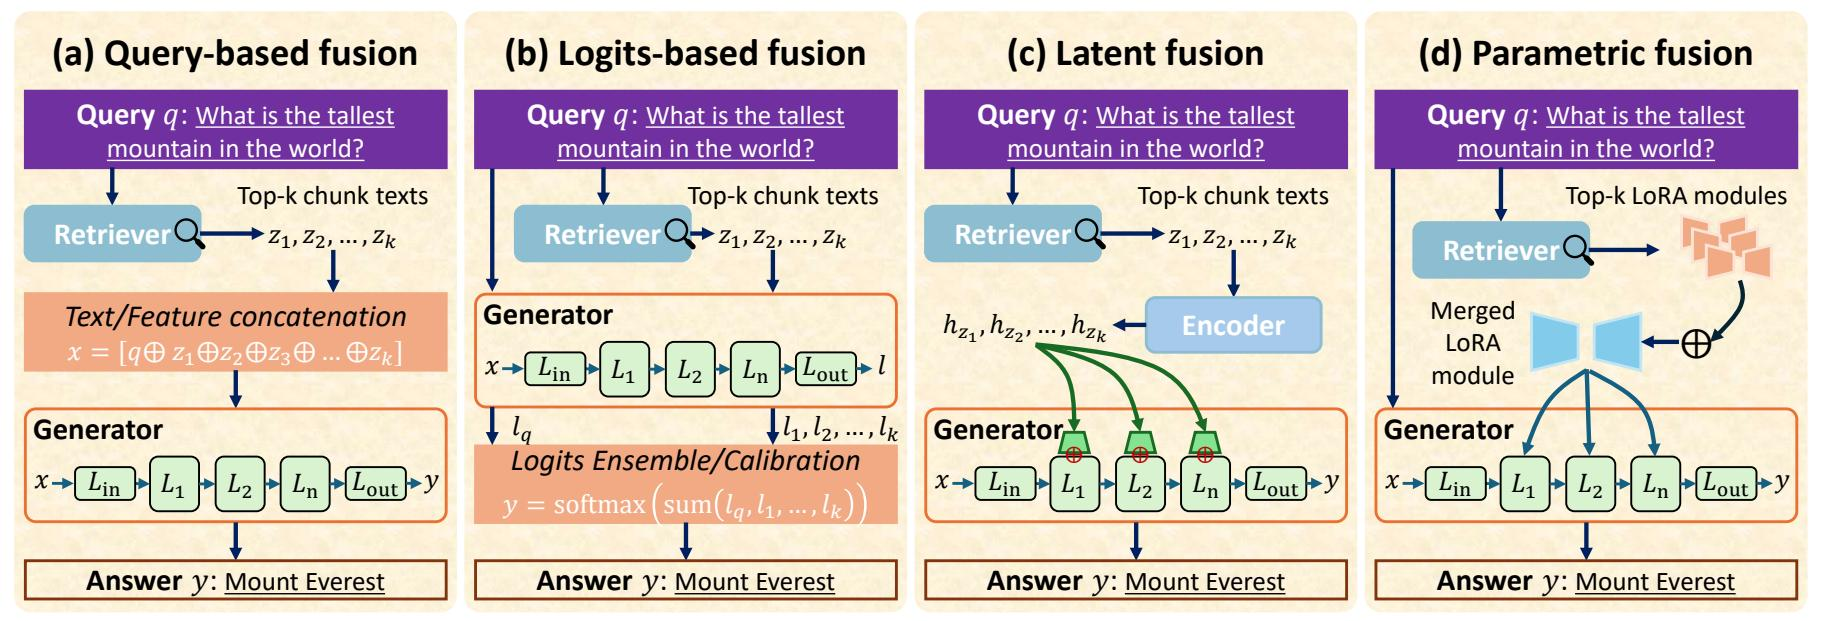

In [154]:
plt_img_base64(img_base64_list[1])

In [155]:
image_summaries = ['The image depicts a schematic comparison of two systems for a process called "RAG," which likely stands for "Retrieval-Augmented Generation." On the left, a system labeled "RAG without KB Update" shows a three-piece process: Training Retriever, Training Generator, and Jointly Training Retriever and Generator, with arrows indicating the workflow between encoder, indexing, knowledge base (KB), retrieval fusions, and generators. On the right, a system labeled "RAG with KB Update" includes two additional stages: Updating KB and Training Generator, with the workflow branching to include retrieval fusions with generative outputs. The image also suggests a process of querying with retrieval fusions and updating training embeddings and corpus, illustrating a flow from query to output with a cyclical update mechanism for the KB.\n',
 'User Safety: safe',
 'User Safety: unsafe\nResponse Safety: unsafe\nSafety Categories: Unauthorized Advice, Fraud/Deception',
 "The image is a structured overview of methods for combining data (fusion methods), models (works), and how these methods vary across criteria like accessibility, memory, latency, and implementation complexity. Each method is categorized under retrieval fusions like 'Query-based', 'Logits-based', and 'Latent' (Attention and Weighted Addition), and examples are given with different memory and latency implications. This image serves as a reference that highlights the trade-offs between complexity, speed, and required resources for each method. For instance, 'Parametric' methods are marked as low in memory and latency but high in implementation complexity, suggesting they are sophisticated but efficient in operation. The scenarios column provides context for when a particular method might be most appropriately used.\n",
 'Based on the provided image, here is a concise summary optimized for retrieval:\n\n**Table Overview:** The image presents a structured table categorizing evaluation metrics for AI systems (likely Retrieval-Augmented Generation models) into four main **Evaluation Focus** areas, detailing dimensions, specific **Metrics**, and **Representative Works** for each.\n\n**Detailed Breakdown:**\n\n1.  **Retrieval Quality:**\n    *   **Dimension:** Context Relevance.\n    *   **Metrics:** Precision@k, Recall@k, Hit Rate, Mean Reciprocal Rank (MRR), Normalized Discounted Cumulative Gain (NDCG).\n    *   **Representative Works:** TREC, MS MARCO, BEIR (Thakur et al. 2021), Domain-specific adaptations (Pipitone and Alami 2024).\n\n2.  **Generation Performance:**\n    *   **Dimension:** Answer Faithfulness (Groundedness).\n        *   **Metrics:** Answer Attribution / Faithfulness Score, Citation Precision/Recall.\n        *   **Representative Works:** RAGAS (ES et al. 2024), ARES (Saad-Falcon et al. 2024), FActScore (Min et al. 2023a), TRUVA (Ni et al. 2025).\n    *   **Dimension:** Answer Relevance.\n        *   **Metrics:** Answer Similarity (BERTScore, ROUGE), LLM-as-a-Judge relevance scoring.\n        *   **Representative Works:** RAGAS (ES et al. 2024), AlpacaEval (Dubois et al. 2024).\n    *   **Dimension:** Answer Correctness.\n        *   **Metrics:** Exact Match (EM), F1 Score, Task-Specific Accuracy.\n        *   **Representative Works:** OpenQA (Siriwardhana et al. 2023), Domain-specific (e.g., Xiong et al. 2024; Hui et al. 2024).\n\n3.  **End-to-End Robustness:**\n    *   **Dimension:** Noise Robustness, Negative Rejection, Information Integration, Counterfactual Robustness.\n    *   **Metrics:** Accuracy, Rejection Rate, Error Detection Rate, Error Correction Rate.\n    *   **Representative Works:** RGB (Chen et al. 2024).\n\n4.  **System-Level Efficiency:**\n    *   **Dimension:** Operational Performance.\n    *   **Metrics:** Latency (p95, p99, TTFT), Cost (USD per query), Throughput, Memory Footprint.\n    *   **Representative Works:** Refusion (Wu et al. 2024), ACIN (Wornow et al. 2024), HedraRAG (Hu et al. 2025b).',
 'User Safety: safe',
 'Based on the image provided, here is a concise summary optimized for retrieval:\n\n**§3 Retriever**: Covers building the retriever (chunking, encoding, index/DB) and querying it (encoding, ANN search, post-processing).\n\n**§4 Retrieval Fusions**: Details fusion methods including query-based, logits-based, latent, parametric, comparison, and hybrid retrieval fusion.\n\n**§5 Generators**: Addresses architectural requirements, generator types, impact of generator design, and practical guidelines for selection.\n\n**§6 Tasks**: Lists application tasks such as language modeling, machine translation, text summarization, question answering, information extraction, text classification, and dialogue systems.\n\n**§7 Evaluation**: Outlines evaluation aspects including a taxonomy of RAG evaluation, key challenges, comparison of evaluation methods, and benchmark limitations.\n\n**§8 RAG Training and KB Update**: Explores training retrievers/generators jointly or separately, with and without knowledge base updates.\n\n**§9 Applications**: Focuses on RAG in industry, available frameworks and libraries, and deployment considerations.\n\n**§10 Discussion and Future Directions**: Covers security and privacy, retrieval quality/efficiency/reliability, RAG vs. Long-Context LLMs, training, cross-modality retrieval, and GraphRAG.']

In [156]:
image_summaries

['The image depicts a schematic comparison of two systems for a process called "RAG," which likely stands for "Retrieval-Augmented Generation." On the left, a system labeled "RAG without KB Update" shows a three-piece process: Training Retriever, Training Generator, and Jointly Training Retriever and Generator, with arrows indicating the workflow between encoder, indexing, knowledge base (KB), retrieval fusions, and generators. On the right, a system labeled "RAG with KB Update" includes two additional stages: Updating KB and Training Generator, with the workflow branching to include retrieval fusions with generative outputs. The image also suggests a process of querying with retrieval fusions and updating training embeddings and corpus, illustrating a flow from query to output with a cyclical update mechanism for the KB.\n',
 'User Safety: safe',
 'User Safety: unsafe\nResponse Safety: unsafe\nSafety Categories: Unauthorized Advice, Fraud/Deception',
 "The image is a structured overvi

In [157]:
del image_summaries[1]

In [158]:
del image_summaries[1]

In [159]:
image_summaries

['The image depicts a schematic comparison of two systems for a process called "RAG," which likely stands for "Retrieval-Augmented Generation." On the left, a system labeled "RAG without KB Update" shows a three-piece process: Training Retriever, Training Generator, and Jointly Training Retriever and Generator, with arrows indicating the workflow between encoder, indexing, knowledge base (KB), retrieval fusions, and generators. On the right, a system labeled "RAG with KB Update" includes two additional stages: Updating KB and Training Generator, with the workflow branching to include retrieval fusions with generative outputs. The image also suggests a process of querying with retrieval fusions and updating training embeddings and corpus, illustrating a flow from query to output with a cyclical update mechanism for the KB.\n',
 "The image is a structured overview of methods for combining data (fusion methods), models (works), and how these methods vary across criteria like accessibility

In [160]:
del image_summaries[3]

In [161]:
image_summaries

['The image depicts a schematic comparison of two systems for a process called "RAG," which likely stands for "Retrieval-Augmented Generation." On the left, a system labeled "RAG without KB Update" shows a three-piece process: Training Retriever, Training Generator, and Jointly Training Retriever and Generator, with arrows indicating the workflow between encoder, indexing, knowledge base (KB), retrieval fusions, and generators. On the right, a system labeled "RAG with KB Update" includes two additional stages: Updating KB and Training Generator, with the workflow branching to include retrieval fusions with generative outputs. The image also suggests a process of querying with retrieval fusions and updating training embeddings and corpus, illustrating a flow from query to output with a cyclical update mechanism for the KB.\n',
 "The image is a structured overview of methods for combining data (fusion methods), models (works), and how these methods vary across criteria like accessibility

In [162]:
len(image_summaries)

4

In [163]:
def looks_like_base64(sb):
  """Check if the string looks like base64"""
  return re.match("^[A-Za-z0-9+/]+[=]{0,2}$", sb) is not None

In [164]:
def is_image_data(b64data):
  """
    Check if the base64 data is an image by looking at the start of the data
  """
  image_signatures = {
      b"\xFF\xD8\xFF": "jpg",
      b"\x89\x50\x4E\x47\x0D\x0A\x1A\x0A": "png",
      b"\x47\x49\x46\x38": "gif",
      b"\x52\x49\x46\x46": "webp",
  }

  try:
    header = base64.b64decode(b64data)[:8] # Decode and get the first 8 bytes
    for sig, format in image_signatures.items():
      if header.startswith(sig):
        return True
    return False

  except Exception:
    return False


In [165]:
def resize_base64_image(base64_string, size=(128, 128)):
  """
    Resize an image encoded as a Base64 string
  """
  # Decode the Base64 string
  img_data = base64.b64decode(base64_string)
  img = Image.open(io.BytesIO(img_data))

  # Resize the image
  resized_img = img.resize(size, Image.LANCZOS)

  # Save the resized image to a bytes buffer
  buffered = io.BytesIO()
  resized_img.save(buffered.getvalue().decode("utf-8"))

In [166]:
def split_image_text_types(docs):
  """
    Split base64-encoded images and texts
  """
  b64_images = []
  texts = []

  for doc in docs:
    # Check if the document is of type Document and extract page_content if so
    if isinstance(doc, Document):
      doc = doc.page_content
    if looks_like_base64(doc) and is_image_data(doc):
      doc = resize_base64_image(doc, size=(1300, 600))
      b64_images.append(doc)
    else:
      texts.append(doc)

  return {"images": b64_images, "texts": texts}

In [167]:
def img_prompt_func(data_dict):
  """
  Join the context into a single string
  """

  #print(data_dict)
  formatted_texts = "\n".join(data_dict["context"]["texts"])
  messages=[]

  # Adding images(s) to the messages if present
  if data_dict["context"]["images"]:
    for image in data_dict["context"]["images"]:
      image_message = {
                "type": "image_url",
                "image_url": {"url": f"data:image/jpeg;base64,{image}"},
            }
      messages.append(image_message)

  # Adding the text for analysis
  text_message = {
        "type": "text",
        "text": (
            "You are a helpful assistant.\n"
            "You will be given a mixed info(s) .\n"
            "Use this information to provide relevant information to the user question. \n"
            f"User-provided question: {data_dict['question']}\n\n"
            "Text and / or tables:\n"
            f"{formatted_texts}"
        ),
  }
  messages.append(text_message)

  return messages


In [168]:
from langchain_core.runnables import RunnableLambda, RunnablePassthrough

In [169]:
def multi_modal_rag_chain(retriever):
  """
  Multi-modal RAG chain
  """

  # Multi-Modal LLM
  modal= model = OpenCLIPEmbeddings()

  # RAG Pipeline
  chain = (
      {
          "context": retriever | RunnableLambda(split_image_text_types),
          "question": RunnablePassthrough(),
      }
      | RunnableLambda(img_prompt_func)
      | model
      | StrOutputParser()
  )

  return chain

In [170]:
# Create RAG chain
chain_multimodal_rag = multi_modal_rag_chain(retriever_multi_vector_img)

In [171]:
chain_multimodal_rag

{
  context: MultiVectorRetriever(vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x7a61081c2f60>, docstore=<langchain_core.stores.InMemoryStore object at 0x7a6106d64770>, search_kwargs={})
           | RunnableLambda(split_image_text_types),
  question: RunnablePassthrough()
}
| RunnableLambda(img_prompt_func)
| ChatOpenRouter(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11', 'langchain-openrouter': '0.2.6'}}, profile={'name': 'Free Models Router', 'release_date': '2026-02-01', 'last_updated': '2026-02-01', 'open_weights': False, 'max_input_tokens': 200000, 'max_output_tokens': 8000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'tool_call_streaming': True}, client=<openrouter.sdk.OpenRout

## Check

In [172]:
# Check retrieval
query = "Why We combine a pre-trained retriever (Query Encoder + Document Index) with a pre-trained seq2seq model (Generator) and fine-tune end-to-end?"
docs = retriever_multi_vector_img.invoke(query)

In [173]:
docs

[]

In [174]:
query="Open-Domain QA Test Scores. For TQA,\
left column uses the standard test set for Open-\
Domain QA, right column uses the TQA-Wiki\
test set. See Appendix D for further details."

In [175]:
docs = retriever_multi_vector_img.invoke(query)

In [176]:
docs = retriever_multi_vector_img.invoke("RAG")

In [177]:
docs

[]

In [178]:
query="Models are trained with either 5 or 10 retrieved latent\
documents, and we do not observe significant differences in performance between them."

In [179]:
retriever_multi_vector_img.invoke(query)

[]

In [180]:
# We get back relevant images
plt_img_base64(docs)

## RAG

In [181]:
query="can you explain me this Left: NQ performance as more documents are retrieved. Center: Retrieval recall performance\
in NQ. Right: MS-MARCO Bleu-1 and Rouge-L as more documents are retrieved."

In [182]:
query1="Explain any images / figures in the paper with Left: NQ performance as more documents are retrieved. Center: Retrieval recall performance\
in NQ. Right: MS-MARCO Bleu-1 and Rouge-L as more documents are retrieved."

In [183]:
# Run RAG chain
chain_multimodal_rag.invoke(query1)

ValueError: Message dict must contain 'role' and 'content' keys, got {'type': 'text', 'text': 'You are a helpful assistant.\nYou will be given a mixed info(s) .\nUse this information to provide relevant information to the user question. \nUser-provided question: Explain any images / figures in the paper with Left: NQ performance as more documents are retrieved. Center: Retrieval recall performancein NQ. Right: MS-MARCO Bleu-1 and Rouge-L as more documents are retrieved.\n\nText and / or tables:\n'}
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/MESSAGE_COERCION_FAILURE 